# Reproduced Figure 1 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Define some physical quantities

This  radius-mass relationship of WD is from Zalamea et al. (2010)

https://academic.oup.com/mnrasl/article/409/1/L25/1003788

In [2]:
# Define the radius-mass relationship of WD
def WD_R_M(M_WD):  # The unit of this obtained value is rg of sun
    return 6120*(M_WD/1.44)**(-1/3)*(1-M_WD/1.44)**(0.447)   

# Define the sqrt of compactness
def WD_eta(M_WD):
    return (M_WD/WD_R_M(M_WD))**(1/2)

# Define rt/rg
def rt_d_rg(M_WD,M_BH): 
    return  WD_eta(M_WD)**(-2)*(M_BH/M_WD)**(-2/3)

## Compute SNR 

P. C. Peters & J. Mathews, “Gravitational Radiation from Point Masses in a Keplerian Orbit” (1963)

https://journals.aps.org/pr/abstract/10.1103/PhysRev.131.435

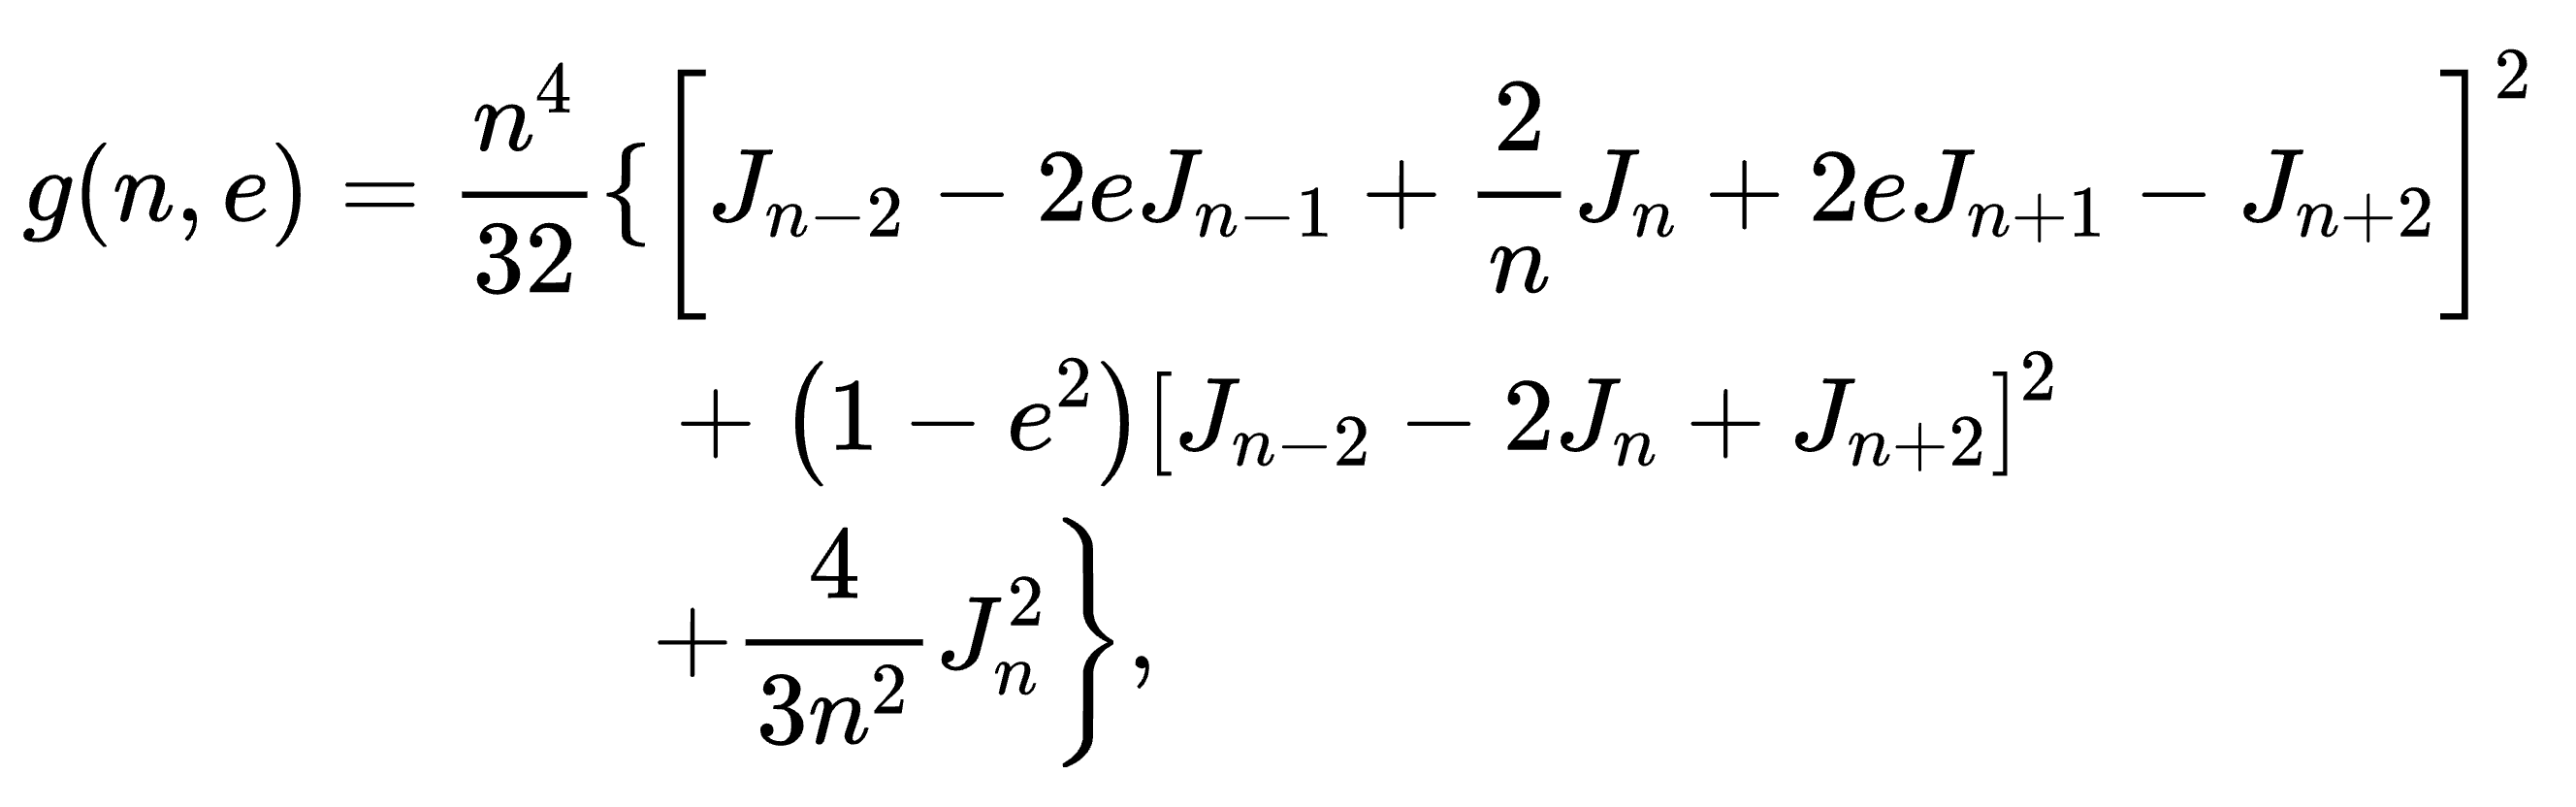

For more details of SNR, you can check Jin-Hong Chen et al. (2022).

https://iopscience.iop.org/article/10.3847/1538-4357/acbfb6/meta



In [3]:
from scipy.special import jv  # Bessel function of the first kind, J_n(x)
from lisatools.sensitivity import get_sensitivity, LISASens


def g_n_e(n, e):
    """
    Compute the Peters & Mathews g(n, e) factor for GW emission 
    from an eccentric binary system.

    Parameters
    ----------
    n : int
        Harmonic number (n ≥ 1)
    e : float
        Orbital eccentricity (0 ≤ e < 1)

    Returns
    -------
    g : float
        Fraction of total GW power emitted in the n-th harmonic
    """
    x = n * e
    # Evaluate Bessel functions at neighboring orders
    Jm2 = jv(n - 2, x)
    Jm1 = jv(n - 1, x)
    J0  = jv(n,     x)
    Jp1 = jv(n + 1, x)
    Jp2 = jv(n + 2, x)

    term1 = Jm2 - 2 * e * Jm1 + (2 / n) * J0 + 2 * e * Jp1 - Jp2
    term2 = Jm2 - 2 * J0 + Jp2
    term3 = J0

    g = (n**4 / 32) * (
            term1**2 +
            (1 - e**2) * term2**2 +
            (4 / (3 * n**2)) * term3**2
    )
    return g


# ===========================================================
from scipy.integrate import quad

# -------- Cosmological parameters --------
H0 = 67.4          # Hubble constant [km/s/Mpc]
c_light = 299792.458     # Speed of light [km/s]
Om = 0.315           # Matter density parameter (Ω_m)
Ol = 1 - Om          # Dark energy density parameter (Ω_Λ), assuming flat ΛCDM cosmology

# -------- Redshift to luminosity distance conversion --------
def redshift_to_dL(z):
    """
    Convert redshift z to luminosity distance d_L in megaparsecs (Mpc),
    assuming a spatially flat ΛCDM universe.

    Note: This function is valid for arbitrary redshifts.
          However, in the context of h_eff, only low-redshift sources are considered,
          because high-redshift signals require modeling frequency evolution over the observation time.

    Parameters
    ----------
    z : float
        Cosmological redshift

    Returns
    -------
    dL : float
        Luminosity distance in Mpc
    """
    # Define the dimensionless expansion rate: E(z) = H(z)/H0
    def E(zp):
        return np.sqrt(Om * (1 + zp)**3 + Ol)
    
    # Numerically integrate to compute the comoving distance
    integral, _ = quad(lambda zp: 1.0 / E(zp), 0, z)
    dL = (1 + z) * (c_light / H0) * integral
    return dL
# ===========================================================


# ===========================================================
# Physical constants in CGS units
c = 2.99792458e10          # Speed of light [cm/s]
year = 3.15576e7           # Seconds in one Julian year [s]
Mpc = 3.08567758e24        # One megaparsec in centimeters [cm]
G = 6.67430e-8             # Gravitational constant [cm³ g⁻¹ s⁻²]
M_sun = 1.98847e33         # Solar mass [g]
Rg_sun = G * M_sun / c**2  # Gravitational radius of the Sun [cm] ≈ 147,667 cm

# Precomputed composite constant (dimensionless scaling factor)
X_constant = c * year * Rg_sun / (Mpc**2)  # ≈ 1.46726 × 10⁻²⁶


def h_eff_n(n, e, rp_rt, M_WD, M_BH, Tobs, z):
    """
    Compute the effective strain amplitude h_eff for the n-th harmonic of an eccentric 
    white dwarf–black hole (WD–BH) binary.

    Parameters
    ----------
    n : int
        Harmonic number
    e : float
        Orbital eccentricity
    rp_rt : float
        Ratio of pericenter distance to tidal radius (r_p / r_t)
    M_WD : float
        White dwarf mass [in solar masses, M_⊙]
    M_BH : float
        Black hole mass [in solar masses, M_⊙]
    Tobs : float
        Observation time [in years]
    z : float
        Source redshift

    Returns
    -------
    h_eff : float
        Effective dimensionless strain amplitude
    """
    return (2 / np.pi) * (
        (32 * g_n_e(n, e) / (5 * n)) *
        (1 - e)**(7/2) *
        2 * np.pi *
        rp_rt**(-7/2) *
        rt_d_rg(M_WD, M_BH)**(-7/2) *
        (M_WD / M_BH)**2 *
        M_BH *
        Tobs / (redshift_to_dL(z)**2) *
        X_constant
    )**(1/2)
# ===========================================================


# ===========================================================
def fre_n(n, e, rp_rt, M_WD, M_BH):
    """
    Compute the gravitational wave frequency f_n of the n-th harmonic for an eccentric WD–BH binary.

    Parameters
    ----------
    n : int
        Harmonic number
    e : float
        Orbital eccentricity
    rp_rt : float
        Pericenter-to-tidal-radius ratio (r_p / r_t)
    M_WD : float
        White dwarf mass [M_⊙]
    M_BH : float
        Black hole mass [M_⊙]

    Returns
    -------
    f_n : float
        Gravitational wave frequency in Hz
    """
    # The constant 2.03248e5 Hz corresponds to the orbital frequency scale for a solar-mass compact object
    return (n / (2 * np.pi)) * (1 - e)**(3/2) * (
        rp_rt**(-3/2) *
        rt_d_rg(M_WD, M_BH)**(-3/2) /
        M_BH *
        2.03248e5  # Base frequency scale in Hz
    )
# ===========================================================


# ===========================================================
# Signal-to-noise ratio (SNR) calculation
def SNR_fun(n_max, e, rp_rt, M_WD, M_BH, Tobs, z):
    """
    Compute the total signal-to-noise ratio (SNR) for an eccentric WD–BH binary,
    by summing contributions from harmonics n = 1 to n_max.

    Parameters
    ----------
    n_max : int
        Maximum harmonic number to include
    e : float
        Orbital eccentricity
    rp_rt : float
        Pericenter-to-tidal-radius ratio
    M_WD : float
        White dwarf mass [M_⊙]
    M_BH : float
        Black hole mass [M_⊙]
    Tobs : float
        Observation duration [years]
    z : float
        Source redshift

    Returns
    -------
    SNR : float
        Total SNR (square root of the sum of squared SNRs from each harmonic)
    """
    n_table = np.linspace(1, n_max, n_max)  # Array of harmonic numbers
    SNR_square_n_table = np.zeros(len(n_table))
    
    for i in range(len(n_table)):
        n_val = n_table[i]
        freq = fre_n(n_val, e, rp_rt, M_WD, M_BH)
        
        # Get LISA's amplitude spectral density (ASD) at this frequency
        sens_ASD = get_sensitivity(
            np.array([freq]),
            sens_fn=LISASens,
            return_type="ASD"
        )[0]
        
        # Accumulate SNR^2 contribution from this harmonic
        SNR_square_n_table[i] = (
            h_eff_n(n_val, e, rp_rt, M_WD, M_BH, Tobs, z)**2
            / (freq * sens_ASD**2)
        )
    
    # Total SNR is the square root of the sum of individual SNR^2 terms
    SNR_result = np.sqrt(np.sum(SNR_square_n_table))
    return SNR_result
# ===========================================================

## Give lines for SNR=10, 20, 40

In [4]:
# for e = 0.95
#=====================
num = 200
M_WD_table = np.linspace(0.1, 1.43,  int( num )  ) # Unit: Solar mass
M_BH_table = 10**( np.linspace(3.2, 6.5,  int(num) ) ) # Unit: Solar mass
#=====================

#=====================
# Here we give the value of rt/rg at (M_WD, M_BH)
rt_rg_table = np.zeros((len(M_WD_table),len(M_BH_table)))
for i in range( len(rt_rg_table) ):
    rt_rg_table[i]=WD_eta(M_WD_table[i])**(-2)*(M_BH_table/M_WD_table[i])**(-2/3)   
log_rt_rg = np.log10(rt_rg_table) 

In [5]:
# Construct two 2D grids for parameter space sampling
num = 200  # Grid resolution
M_WD_table = np.linspace(0.001, 1.438, int(num))      # White dwarf mass [in solar masses, M_⊙]
M_BH_table = 10**(np.linspace(2, 7, int(num)))        # Black hole mass [in solar masses, M_⊙]

# Precompute net_1 = (r_t / r_g)^(-2) * M_WD^2
net_1 = np.zeros((len(M_WD_table), len(M_BH_table)))
for i in range(len(rt_rg_table)):
    for j in range(len(rt_rg_table[0])):
        net_1[i][j] = rt_d_rg(M_WD_table[i], M_BH_table[j])**(-2) * M_WD_table[i]**2

# Precompute net_2 = (r_t / r_g)^(-3/2) / M_BH
net_2 = np.zeros((len(M_WD_table), len(M_BH_table)))
for i in range(len(rt_rg_table)):
    for j in range(len(rt_rg_table[0])):
        net_2[i][j] = rt_d_rg(M_WD_table[i], M_BH_table[j])**(-3/2) / M_BH_table[j]
#=========================================================================

# Compute SNR contour for SNR = 10
for fig1 in range(1):
    #======================================================================
    # Fixed observational and orbital parameters
    Tobs = 4          # Observation time [years]
    z = 0.02          # Redshift
    e_fig = 0.95      # Eccentricity
    rp_rt_fig = 2     # Pericenter-to-tidal-radius ratio

    # Precomputed constants for efficiency
    const_1 = (4 / np.pi**2) * (32 / 5) * (1 - e_fig)**2 * (2 * np.pi)**2 * rp_rt_fig**(-2) * Tobs / redshift_to_dL(z)**2 * X_constant
    const_2 = (1 / (2 * np.pi)) * (1 - e_fig)**(3/2) * rp_rt_fig**(-3/2)

    # First part of SNR expression: depends on net_1
    part_1 = (const_1 * net_1)**(1/2)

    # Second part: sum over harmonics (n = 1 to n_max)
    n_max = 500  # Number of harmonics needed for highly eccentric orbits
    part_2 = np.zeros((len(M_WD_table), len(M_BH_table)))
    
    # Base frequency scaling factor: c^3 / (G * M_sun) ≈ 202974.33 Hz
    freq_scale = 202974.3331910614
    part_21 = (const_2 * net_2) * freq_scale

    for n_idx in range(1, n_max + 1):
        term1 = g_n_e(n_idx, e_fig) / (n_idx**2 * freq_scale)
        term2 = get_sensitivity(
            n_idx * part_21,
            sens_fn=LISASens,
            return_type="ASD"
        )**2
        part_2 += term1 / term2

    SNR_table = part_1 * part_2**(1/2)
    #======================================================================================

    # Extract SNR = 10 contour and build interpolation function
    from scipy.interpolate import interp1d
    SNR_line = 10

    # Step 1: Generate contour without displaying it
    contour_set = plt.contour(M_WD_table, M_BH_table, SNR_table.T, levels=[SNR_line])  # Note: transpose is essential!
    plt.close()  # Prevent figure window from appearing

    # Step 2: Extract contour points using .allsegs
    all_segments = contour_set.allsegs[0]  # Only one level → index 0
    if len(all_segments) == 0:
        raise ValueError("No contour found at SNR = 10!")

    # Combine all disconnected segments (if any)
    points_list = []
    for seg in all_segments:
        if seg.shape[0] > 1:  # Require at least two points
            points_list.append(seg)
    if not points_list:
        raise ValueError("No valid segments in SNR=10 contour.")

    all_points = np.vstack(points_list)  # Shape: (K, 2); columns = [M_WD, M_BH]
    M_WD_vals = all_points[:, 0]
    M_BH_vals = all_points[:, 1]

    # Sort by M_WD to ensure monotonicity for interpolation
    sort_idx = np.argsort(M_WD_vals)
    M_WD_sorted = M_WD_vals[sort_idx]
    M_BH_sorted = M_BH_vals[sort_idx]

    # Remove duplicate M_WD values (keep first occurrence)
    _, unique_idx = np.unique(M_WD_sorted, return_index=True)
    M_WD_unique = M_WD_sorted[unique_idx]
    M_BH_unique = M_BH_sorted[unique_idx]

    # Step 3: Create interpolation function
    try:
        SNR_interp_func = interp1d(
            M_WD_unique,
            M_BH_unique,
            kind='linear',
            bounds_error=False,
            fill_value=np.nan
        )
    except Exception as e:
        print("Interpolation failed—contour may be multi-valued in M_WD.")
        raise e

SNR_interp_func11 = SNR_interp_func


# Repeat for SNR = 20
for fig2 in range(1):
    #======================================================================================
    Tobs = 4
    z = 0.02
    e_fig = 0.95
    rp_rt_fig = 2
    const_1 = (4 / np.pi**2) * (32 / 5) * (1 - e_fig)**2 * (2 * np.pi)**2 * rp_rt_fig**(-2) * Tobs / redshift_to_dL(z)**2 * X_constant
    const_2 = (1 / (2 * np.pi)) * (1 - e_fig)**(3/2) * rp_rt_fig**(-3/2)
    part_1 = (const_1 * net_1)**(1/2)
    n_max = 500
    part_2 = np.zeros((len(M_WD_table), len(M_BH_table)))
    part_21 = (const_2 * net_2) * 202974.3331910614
    for n_idx in range(1, n_max + 1):
        term1 = g_n_e(n_idx, e_fig) / (n_idx**2 * 202974.3331910614)
        term2 = get_sensitivity(n_idx * part_21, sens_fn=LISASens, return_type="ASD")**2
        part_2 += term1 / term2
    SNR_table = part_1 * part_2**(1/2)
    #======================================================================================

    from scipy.interpolate import interp1d
    SNR_line = 20
    contour_set = plt.contour(M_WD_table, M_BH_table, SNR_table.T, levels=[SNR_line])
    plt.close()
    all_segments = contour_set.allsegs[0]
    if len(all_segments) == 0:
        raise ValueError("No contour found at SNR = 20!")
    points_list = []
    for seg in all_segments:
        if seg.shape[0] > 1:
            points_list.append(seg)
    if not points_list:
        raise ValueError("No valid segments in SNR=20 contour.")
    all_points = np.vstack(points_list)
    M_WD_vals = all_points[:, 0]
    M_BH_vals = all_points[:, 1]
    sort_idx = np.argsort(M_WD_vals)
    M_WD_sorted = M_WD_vals[sort_idx]
    M_BH_sorted = M_BH_vals[sort_idx]
    _, unique_idx = np.unique(M_WD_sorted, return_index=True)
    M_WD_unique = M_WD_sorted[unique_idx]
    M_BH_unique = M_BH_sorted[unique_idx]
    try:
        SNR_interp_func = interp1d(M_WD_unique, M_BH_unique, kind='linear', bounds_error=False, fill_value=np.nan)
    except Exception as e:
        print("Interpolation failed—contour may be multi-valued in M_WD.")
        raise e

SNR_interp_func22 = SNR_interp_func


# Repeat for SNR = 30
for fig3 in range(1):
    #======================================================================================
    Tobs = 4
    z = 0.02
    e_fig = 0.95
    rp_rt_fig = 2
    const_1 = (4 / np.pi**2) * (32 / 5) * (1 - e_fig)**2 * (2 * np.pi)**2 * rp_rt_fig**(-2) * Tobs / redshift_to_dL(z)**2 * X_constant
    const_2 = (1 / (2 * np.pi)) * (1 - e_fig)**(3/2) * rp_rt_fig**(-3/2)
    part_1 = (const_1 * net_1)**(1/2)
    n_max = 500
    part_2 = np.zeros((len(M_WD_table), len(M_BH_table)))
    part_21 = (const_2 * net_2) * 202974.3331910614
    for n_idx in range(1, n_max + 1):
        term1 = g_n_e(n_idx, e_fig) / (n_idx**2 * 202974.3331910614)
        term2 = get_sensitivity(n_idx * part_21, sens_fn=LISASens, return_type="ASD")**2
        part_2 += term1 / term2
    SNR_table = part_1 * part_2**(1/2)
    #======================================================================================

    from scipy.interpolate import interp1d
    SNR_line = 30
    contour_set = plt.contour(M_WD_table, M_BH_table, SNR_table.T, levels=[SNR_line])
    plt.close()
    all_segments = contour_set.allsegs[0]
    if len(all_segments) == 0:
        raise ValueError("No contour found at SNR = 30!")
    points_list = []
    for seg in all_segments:
        if seg.shape[0] > 1:
            points_list.append(seg)
    if not points_list:
        raise ValueError("No valid segments in SNR=30 contour.")
    all_points = np.vstack(points_list)
    M_WD_vals = all_points[:, 0]
    M_BH_vals = all_points[:, 1]
    sort_idx = np.argsort(M_WD_vals)
    M_WD_sorted = M_WD_vals[sort_idx]
    M_BH_sorted = M_BH_vals[sort_idx]
    _, unique_idx = np.unique(M_WD_sorted, return_index=True)
    M_WD_unique = M_WD_sorted[unique_idx]
    M_BH_unique = M_BH_sorted[unique_idx]
    try:
        SNR_interp_func = interp1d(M_WD_unique, M_BH_unique, kind='linear', bounds_error=False, fill_value=np.nan)
    except Exception as e:
        print("Interpolation failed—contour may be multi-valued in M_WD.")
        raise e

SNR_interp_func33 = SNR_interp_func


# Repeat for SNR = 40
for fig4 in range(1):
    #======================================================================================
    Tobs = 4
    z = 0.02
    e_fig = 0.95
    rp_rt_fig = 2
    const_1 = (4 / np.pi**2) * (32 / 5) * (1 - e_fig)**2 * (2 * np.pi)**2 * rp_rt_fig**(-2) * Tobs / redshift_to_dL(z)**2 * X_constant
    const_2 = (1 / (2 * np.pi)) * (1 - e_fig)**(3/2) * rp_rt_fig**(-3/2)
    part_1 = (const_1 * net_1)**(1/2)
    n_max = 500
    part_2 = np.zeros((len(M_WD_table), len(M_BH_table)))
    part_21 = (const_2 * net_2) * 202974.3331910614
    for n_idx in range(1, n_max + 1):
        term1 = g_n_e(n_idx, e_fig) / (n_idx**2 * 202974.3331910614)
        term2 = get_sensitivity(n_idx * part_21, sens_fn=LISASens, return_type="ASD")**2
        part_2 += term1 / term2
    SNR_table = part_1 * part_2**(1/2)
    #======================================================================================

    from scipy.interpolate import interp1d
    SNR_line = 40
    contour_set = plt.contour(M_WD_table, M_BH_table, SNR_table.T, levels=[SNR_line])
    plt.close()
    all_segments = contour_set.allsegs[0]
    if len(all_segments) == 0:
        raise ValueError("No contour found at SNR = 40!")
    points_list = []
    for seg in all_segments:
        if seg.shape[0] > 1:
            points_list.append(seg)
    if not points_list:
        raise ValueError("No valid segments in SNR=40 contour.")
    all_points = np.vstack(points_list)
    M_WD_vals = all_points[:, 0]
    M_BH_vals = all_points[:, 1]
    sort_idx = np.argsort(M_WD_vals)
    M_WD_sorted = M_WD_vals[sort_idx]
    M_BH_sorted = M_BH_vals[sort_idx]
    _, unique_idx = np.unique(M_WD_sorted, return_index=True)
    M_WD_unique = M_WD_sorted[unique_idx]
    M_BH_unique = M_BH_sorted[unique_idx]
    try:
        SNR_interp_func = interp1d(M_WD_unique, M_BH_unique, kind='linear', bounds_error=False, fill_value=np.nan)
    except Exception as e:
        print("Interpolation failed—contour may be multi-valued in M_WD.")
        raise e

SNR_interp_func44 = SNR_interp_func

#==============================================================
# Plot all four SNR contours
# plt.plot(M_WD_table, SNR_interp_func11(M_WD_table), label='SNR = 10')
# plt.plot(M_WD_table, SNR_interp_func22(M_WD_table), label='SNR = 20')
# plt.plot(M_WD_table, SNR_interp_func33(M_WD_table), label='SNR = 30')
# plt.plot(M_WD_table, SNR_interp_func44(M_WD_table), label='SNR = 40')

# # Apply logarithmic scaling and set axis limits
# plt.yscale('log')
# plt.xscale('log')
# plt.ylim(10**2.6, 10**6.5)
# plt.xlim(0.1, 1.425)

In [6]:
# for e=0.99
#=====================================
num = 200  # Grid resolution
M_WD_table = np.linspace(0.001, 1.438, int(num))  # Units: solar masses
M_BH_table = 10**(np.linspace(2, 7, int(num)))    # Units: solar masses

net_1 = np.zeros((len(M_WD_table), len(M_BH_table)))
for i in range(len(rt_rg_table)):
    for j in range(len(rt_rg_table[0])):
        net_1[i][j] = rt_d_rg(M_WD_table[i], M_BH_table[j])**(-2) * M_WD_table[i]**2

net_2 = np.zeros((len(M_WD_table), len(M_BH_table)))
for i in range(len(rt_rg_table)):
    for j in range(len(rt_rg_table[0])):
        net_2[i][j] = rt_d_rg(M_WD_table[i], M_BH_table[j])**(-3/2) / M_BH_table[j]
#===============================================================

for fig1 in range(1):
    #============================================================
    # Compute two fixed constants
    Tobs = 4
    z = 0.02 
    e_fig = 0.99
    rp_rt_fig = 2
    const_1 = 4 / np.pi**2 * 32 / 5 * (1 - e_fig)**2 * (2 * np.pi)**2 * rp_rt_fig**(-2) * Tobs / redshift_to_dL(z)**2 * X_constant
    const_2 = 1 / (2 * np.pi) * (1 - e_fig)**(3/2) * rp_rt_fig**(-3/2)
    # Part from the first constant
    part_1 = (const_1 * net_1)**(1/2)
    # Compute contribution from each harmonic n; do not store intermediate grids—accumulate directly
    n_max = 500  # Number of harmonics required for highly eccentric orbits
    part_2 = np.zeros((len(M_WD_table), len(M_BH_table)))
    part_21 = (const_2 * net_2) * 202974.3331910614 
    for n_idx in range(1, n_max + 1):
        # Note: c^3 / (G * M_sun) = 202974.3331910614 Hz
        term1 = g_n_e(n_idx, e_fig) / (n_idx**2 * 202974.3331910614)
        term2 = get_sensitivity(
            n_idx * part_21,
            sens_fn=LISASens,
            return_type="ASD"
        )**2
        part_2 += term1 / term2
    SNR_table = part_1 * part_2**(1/2)
    #============================================================

    #============================================================
    from scipy.interpolate import interp1d
    SNR_line = 10
    # Step 1: Create contour object (do not display)
    contour_set = plt.contour(M_WD_table, M_BH_table, SNR_table.T, levels=[SNR_line])  # Transpose! Critical.
    plt.close()  # Prevent figure window from popping up
    # Step 2: Extract contour points (using .allsegs)
    all_segments = contour_set.allsegs[0]  # Only one level (SNR=10)
    if len(all_segments) == 0:
        raise ValueError("No contour found at SNR = 10!")
    # Merge all segments (there may be multiple disconnected curves)
    points_list = []
    for seg in all_segments:
        if seg.shape[0] > 1:  # At least two points
            points_list.append(seg)
    if not points_list:
        raise ValueError("No valid segments in SNR=10 contour.")
    all_points = np.vstack(points_list)  # Shape (K, 2); columns: [M_WD, M_BH]
    M_WD_vals = all_points[:, 0]
    M_BH_vals = all_points[:, 1]
    # Remove duplicates and sort (to avoid non-monotonic x during interpolation)
    # Sort by M_WD
    sort_idx = np.argsort(M_WD_vals)
    M_WD_sorted = M_WD_vals[sort_idx]
    M_BH_sorted = M_BH_vals[sort_idx]
    # Remove duplicate M_WD values (keep first occurrence)
    _, unique_idx = np.unique(M_WD_sorted, return_index=True)
    M_WD_unique = M_WD_sorted[unique_idx]
    M_BH_unique = M_BH_sorted[unique_idx]
    # Step 3: Build interpolation function
    try:
        SNR_interp_func = interp1d(
            M_WD_unique,
            M_BH_unique,
            kind='linear',
            bounds_error=False,
            fill_value=np.nan
        )
    except Exception as e:
        print("Interpolation failed—contour may be multi-valued in M_WD.")
        raise e
SNR_interp_func111 = SNR_interp_func

for fig2 in range(1):
    #=================================================
    # Compute two fixed constants
    Tobs = 4
    z = 0.02 
    e_fig = 0.99
    rp_rt_fig = 2
    const_1 = 4 / np.pi**2 * 32 / 5 * (1 - e_fig)**2 * (2 * np.pi)**2 * rp_rt_fig**(-2) * Tobs / redshift_to_dL(z)**2 * X_constant
    const_2 = 1 / (2 * np.pi) * (1 - e_fig)**(3/2) * rp_rt_fig**(-3/2)
    # Part from the first constant
    part_1 = (const_1 * net_1)**(1/2)
    # Compute contribution from each harmonic n; do not store intermediate grids—accumulate directly
    n_max = 500  # Number of harmonics required for highly eccentric orbits
    part_2 = np.zeros((len(M_WD_table), len(M_BH_table)))
    part_21 = (const_2 * net_2) * 202974.3331910614 
    for n_idx in range(1, n_max + 1):
        # Note: c^3 / (G * M_sun) = 202974.3331910614 Hz
        term1 = g_n_e(n_idx, e_fig) / (n_idx**2 * 202974.3331910614)
        term2 = get_sensitivity(
            n_idx * part_21,
            sens_fn=LISASens,
            return_type="ASD"
        )**2
        part_2 += term1 / term2
    SNR_table = part_1 * part_2**(1/2)
    #=================================================

    #=================================================
    from scipy.interpolate import interp1d
    SNR_line = 20
    # Step 1: Create contour object (do not display)
    contour_set = plt.contour(M_WD_table, M_BH_table, SNR_table.T, levels=[SNR_line])  # Transpose! Critical.
    plt.close()  # Prevent figure window from popping up
    # Step 2: Extract contour points (using .allsegs)
    all_segments = contour_set.allsegs[0]  # Only one level (SNR=20)
    if len(all_segments) == 0:
        raise ValueError("No contour found at SNR = 20!")
    # Merge all segments (there may be multiple disconnected curves)
    points_list = []
    for seg in all_segments:
        if seg.shape[0] > 1:  # At least two points
            points_list.append(seg)
    if not points_list:
        raise ValueError("No valid segments in SNR=20 contour.")
    all_points = np.vstack(points_list)  # Shape (K, 2); columns: [M_WD, M_BH]
    M_WD_vals = all_points[:, 0]
    M_BH_vals = all_points[:, 1]
    # Remove duplicates and sort (to avoid non-monotonic x during interpolation)
    # Sort by M_WD
    sort_idx = np.argsort(M_WD_vals)
    M_WD_sorted = M_WD_vals[sort_idx]
    M_BH_sorted = M_BH_vals[sort_idx]
    # Remove duplicate M_WD values (keep first occurrence)
    _, unique_idx = np.unique(M_WD_sorted, return_index=True)
    M_WD_unique = M_WD_sorted[unique_idx]
    M_BH_unique = M_BH_sorted[unique_idx]
    # Step 3: Build interpolation function
    try:
        SNR_interp_func = interp1d(
            M_WD_unique,
            M_BH_unique,
            kind='linear',
            bounds_error=False,
            fill_value=np.nan
        )
    except Exception as e:
        print("Interpolation failed—contour may be multi-valued in M_WD.")
        raise e
SNR_interp_func222 = SNR_interp_func

for fig3 in range(1):
    #=================================================
    # Compute two fixed constants
    Tobs = 4
    z = 0.02 
    e_fig = 0.99
    rp_rt_fig = 2
    const_1 = 4 / np.pi**2 * 32 / 5 * (1 - e_fig)**2 * (2 * np.pi)**2 * rp_rt_fig**(-2) * Tobs / redshift_to_dL(z)**2 * X_constant
    const_2 = 1 / (2 * np.pi) * (1 - e_fig)**(3/2) * rp_rt_fig**(-3/2)
    # Part from the first constant
    part_1 = (const_1 * net_1)**(1/2)
    # Compute contribution from each harmonic n; do not store intermediate grids—accumulate directly
    n_max = 500  # Number of harmonics required for highly eccentric orbits
    part_2 = np.zeros((len(M_WD_table), len(M_BH_table)))
    part_21 = (const_2 * net_2) * 202974.3331910614 
    for n_idx in range(1, n_max + 1):
        # Note: c^3 / (G * M_sun) = 202974.3331910614 Hz
        term1 = g_n_e(n_idx, e_fig) / (n_idx**2 * 202974.3331910614)
        term2 = get_sensitivity(
            n_idx * part_21,
            sens_fn=LISASens,
            return_type="ASD"
        )**2
        part_2 += term1 / term2
    SNR_table = part_1 * part_2**(1/2)
    #=================================================

    #=================================================
    from scipy.interpolate import interp1d
    SNR_line = 30
    # Step 1: Create contour object (do not display)
    contour_set = plt.contour(M_WD_table, M_BH_table, SNR_table.T, levels=[SNR_line])  # Transpose! Critical.
    plt.close()  # Prevent figure window from popping up
    # Step 2: Extract contour points (using .allsegs)
    all_segments = contour_set.allsegs[0]  # Only one level (SNR=30)
    if len(all_segments) == 0:
        raise ValueError("No contour found at SNR = 30!")
    # Merge all segments (there may be multiple disconnected curves)
    points_list = []
    for seg in all_segments:
        if seg.shape[0] > 1:  # At least two points
            points_list.append(seg)
    if not points_list:
        raise ValueError("No valid segments in SNR=30 contour.")
    all_points = np.vstack(points_list)  # Shape (K, 2); columns: [M_WD, M_BH]
    M_WD_vals = all_points[:, 0]
    M_BH_vals = all_points[:, 1]
    # Remove duplicates and sort (to avoid non-monotonic x during interpolation)
    # Sort by M_WD
    sort_idx = np.argsort(M_WD_vals)
    M_WD_sorted = M_WD_vals[sort_idx]
    M_BH_sorted = M_BH_vals[sort_idx]
    # Remove duplicate M_WD values (keep first occurrence)
    _, unique_idx = np.unique(M_WD_sorted, return_index=True)
    M_WD_unique = M_WD_sorted[unique_idx]
    M_BH_unique = M_BH_sorted[unique_idx]
    # Step 3: Build interpolation function
    try:
        SNR_interp_func = interp1d(
            M_WD_unique,
            M_BH_unique,
            kind='linear',
            bounds_error=False,
            fill_value=np.nan
        )
    except Exception as e:
        print("Interpolation failed—contour may be multi-valued in M_WD.")
        raise e
SNR_interp_func333 = SNR_interp_func

for fig4 in range(1):
    #=================================================
    # Compute two fixed constants
    Tobs = 4
    z = 0.02 
    e_fig = 0.99
    rp_rt_fig = 2
    const_1 = 4 / np.pi**2 * 32 / 5 * (1 - e_fig)**2 * (2 * np.pi)**2 * rp_rt_fig**(-2) * Tobs / redshift_to_dL(z)**2 * X_constant
    const_2 = 1 / (2 * np.pi) * (1 - e_fig)**(3/2) * rp_rt_fig**(-3/2)
    # Part from the first constant
    part_1 = (const_1 * net_1)**(1/2)
    # Compute contribution from each harmonic n; do not store intermediate grids—accumulate directly
    n_max = 500  # Number of harmonics required for highly eccentric orbits
    part_2 = np.zeros((len(M_WD_table), len(M_BH_table)))
    part_21 = (const_2 * net_2) * 202974.3331910614 
    for n_idx in range(1, n_max + 1):
        # Note: c^3 / (G * M_sun) = 202974.3331910614 Hz
        term1 = g_n_e(n_idx, e_fig) / (n_idx**2 * 202974.3331910614)
        term2 = get_sensitivity(
            n_idx * part_21,
            sens_fn=LISASens,
            return_type="ASD"
        )**2
        part_2 += term1 / term2
    SNR_table = part_1 * part_2**(1/2)
    #=================================================

    #=================================================
    from scipy.interpolate import interp1d
    SNR_line = 40
    # Step 1: Create contour object (do not display)
    contour_set = plt.contour(M_WD_table, M_BH_table, SNR_table.T, levels=[SNR_line])  # Transpose! Critical.
    plt.close()  # Prevent figure window from popping up
    # Step 2: Extract contour points (using .allsegs)
    all_segments = contour_set.allsegs[0]  # Only one level (SNR=40)
    if len(all_segments) == 0:
        raise ValueError("No contour found at SNR = 40!")
    # Merge all segments (there may be multiple disconnected curves)
    points_list = []
    for seg in all_segments:
        if seg.shape[0] > 1:  # At least two points
            points_list.append(seg)
    if not points_list:
        raise ValueError("No valid segments in SNR=40 contour.")
    all_points = np.vstack(points_list)  # Shape (K, 2); columns: [M_WD, M_BH]
    M_WD_vals = all_points[:, 0]
    M_BH_vals = all_points[:, 1]
    # Remove duplicates and sort (to avoid non-monotonic x during interpolation)
    # Sort by M_WD
    sort_idx = np.argsort(M_WD_vals)
    M_WD_sorted = M_WD_vals[sort_idx]
    M_BH_sorted = M_BH_vals[sort_idx]
    # Remove duplicate M_WD values (keep first occurrence)
    _, unique_idx = np.unique(M_WD_sorted, return_index=True)
    M_WD_unique = M_WD_sorted[unique_idx]
    M_BH_unique = M_BH_sorted[unique_idx]
    # Step 3: Build interpolation function
    try:
        SNR_interp_func = interp1d(
            M_WD_unique,
            M_BH_unique,
            kind='linear',
            bounds_error=False,
            fill_value=np.nan
        )
    except Exception as e:
        print("Interpolation failed—contour may be multi-valued in M_WD.")
        raise e
SNR_interp_func444 = SNR_interp_func

#=================================================
# plt.plot(M_WD_table, SNR_interp_func111(M_WD_table))
# plt.plot(M_WD_table, SNR_interp_func222(M_WD_table))
# plt.plot(M_WD_table, SNR_interp_func333(M_WD_table))
# plt.plot(M_WD_table, SNR_interp_func444(M_WD_table))
# plt.yscale('log')
# plt.xscale('log')
# plt.ylim(10**(2.6), 10**(6.5))
# plt.xlim(0.1, 1.425)

## beyond the quadrupole moment

compute R_WD / r_t = (M_WD / M_BH)^(1/3)

In [7]:
# Include consideration of tidal fields beyond the quadrupole moment: compute R_WD / rt = (M_WD / M_BH)^(1/3)
M_WD_table = np.linspace(0.01, 1.43, int(num))  # Units: solar masses
M_BH_table = 10**(np.linspace(2.5, 6.2, int(num)))  # Units: solar masses

# Whether to include forces beyond the quadrupole moment
RWD_rt_table = np.zeros((len(M_WD_table), len(M_BH_table)))
for i in range(len(rt_rg_table)):
    for j in range(len(rt_rg_table[0])):
        RWD_rt_table[i][j] = (M_WD_table[i] / M_BH_table[j])**(1/3)

# Reference line for equal mass ratio
Mass_ratio_table = np.zeros((len(M_WD_table), len(M_BH_table)))
for i in range(len(Mass_ratio_table)):
    for j in range(len(Mass_ratio_table[0])):
        Mass_ratio_table[i][j] = (M_WD_table[i] / M_BH_table[j])**(1)
#==========================================================================

# Whether to include forces beyond the quadrupole moment
#==========================================================================
for iiii1 in range(1):
    from scipy.interpolate import interp1d
    RWD_rt_line = 0.05   # 5% significance threshold
    # Step 1: Create contour object (do not display)
    contour_set = plt.contour(M_WD_table, M_BH_table,
                              RWD_rt_table.T, levels=[RWD_rt_line])  # Transpose! Critical.
    plt.close()  # Prevent figure window from popping up
    # Step 2: Extract contour points (using .allsegs)
    all_segments = contour_set.allsegs[0]  # Only one level
    if len(all_segments) == 0:
        raise ValueError("No contour found at R_WD/rt = 0.05!")
    # Merge all segments (there may be multiple disconnected curves)
    points_list = []
    for seg in all_segments:
        if seg.shape[0] > 1:  # At least two points
            points_list.append(seg)
    if not points_list:
        raise ValueError("No valid segments in R_WD/rt = 0.05 contour.")
    all_points = np.vstack(points_list)  # Shape (K, 2), columns: [M_WD, M_BH]
    M_WD_vals = all_points[:, 0]
    M_BH_vals = all_points[:, 1]
    # Remove duplicates and sort (to avoid non-monotonic x during interpolation)
    # Sort by M_WD
    sort_idx = np.argsort(M_WD_vals)
    M_WD_sorted = M_WD_vals[sort_idx]
    M_BH_sorted = M_BH_vals[sort_idx]
    # Remove duplicate M_WD values (keep first occurrence)
    _, unique_idx = np.unique(M_WD_sorted, return_index=True)
    M_WD_unique = M_WD_sorted[unique_idx]
    M_BH_unique = M_BH_sorted[unique_idx]
    # Step 3: Build interpolation function
    try:
        RWD_rt_interp_func = interp1d(
            M_WD_unique,
            M_BH_unique,
            kind='linear',
            bounds_error=False,
            fill_value=np.nan
        )
    except Exception as e:
        print("Interpolation failed—contour may be multi-valued in M_WD.")
        raise e
RWD_rt_interp_func1 = RWD_rt_interp_func

# Reference line for equal mass ratio
#==========================================================================
for iiii1 in range(1):
    from scipy.interpolate import interp1d
    Mass_ratio_line = 1e-6   # Mass ratio threshold
    # Step 1: Create contour object (do not display)
    contour_set = plt.contour(M_WD_table, M_BH_table,
                              Mass_ratio_table.T, levels=[Mass_ratio_line])  # Transpose! Critical.
    plt.close()  # Prevent figure window from popping up
    # Step 2: Extract contour points (using .allsegs)
    all_segments = contour_set.allsegs[0]  # Only one level
    if len(all_segments) == 0:
        raise ValueError("No contour found at mass ratio = 1e-6!")
    # Merge all segments (there may be multiple disconnected curves)
    points_list = []
    for seg in all_segments:
        if seg.shape[0] > 1:  # At least two points
            points_list.append(seg)
    if not points_list:
        raise ValueError("No valid segments in mass ratio = 1e-6 contour.")
    all_points = np.vstack(points_list)  # Shape (K, 2), columns: [M_WD, M_BH]
    M_WD_vals = all_points[:, 0]
    M_BH_vals = all_points[:, 1]
    # Remove duplicates and sort (to avoid non-monotonic x during interpolation)
    # Sort by M_WD
    sort_idx = np.argsort(M_WD_vals)
    M_WD_sorted = M_WD_vals[sort_idx]
    M_BH_sorted = M_BH_vals[sort_idx]
    # Remove duplicate M_WD values (keep first occurrence)
    _, unique_idx = np.unique(M_WD_sorted, return_index=True)
    M_WD_unique = M_WD_sorted[unique_idx]
    M_BH_unique = M_BH_sorted[unique_idx]
    # Step 3: Build interpolation function
    try:
        Mass_ratio_interp_func = interp1d(
            M_WD_unique,
            M_BH_unique,
            kind='linear',
            bounds_error=False,
            fill_value=np.nan
        )
    except Exception as e:
        print("Interpolation failed—contour may be multi-valued in M_WD.")
        raise e
Mass_ratio_interp_func1 = Mass_ratio_interp_func

In [8]:
import matplotlib.cm as cm
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LogNorm
#=====================

#=====================
num = 200
M_WD_table = np.linspace(0.1, 1.43,  int( num )  ) # Unit: Solar mass
M_BH_table = 10**( np.linspace(3.2, 6.5,  int(num) ) ) # Unit: Solar mass
#=====================

#=====================
# Here we give the value of rt/rg at (M_WD,M_BH)
rt_rg_table = np.zeros((len(M_WD_table),len(M_BH_table)))
for i in range( len(rt_rg_table) ):
    rt_rg_table[i]=WD_eta(M_WD_table[i])**(-2)*(M_BH_table/M_WD_table[i])**(-2/3)   
log_rt_rg = np.log10(rt_rg_table) 

## Main drawing

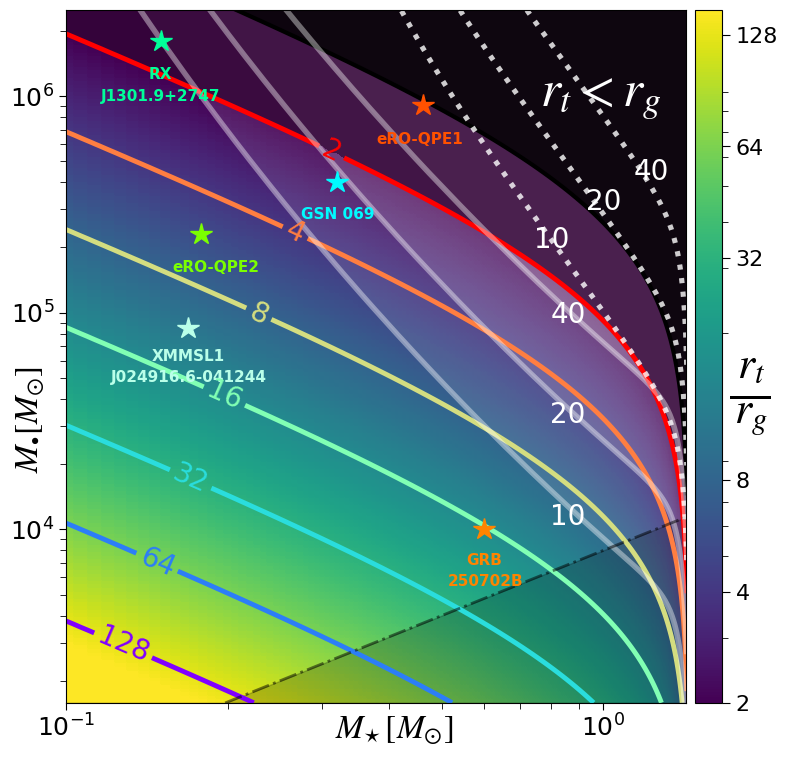

In [12]:
# Please execute this code cell twice repeatedly, so that the font can be executed

# Create 2D mesh grids for black hole mass (M_BH) and white dwarf mass (M_WD)
M_BH_mesh, M_WD_mesh = np.meshgrid(M_BH_table, M_WD_table)
# =====================

# =====================
plt.figure(figsize=(10, 9))
# =====================

# =====================
# Use the original rt_rg_table, but apply logarithmic normalization for better visualization
norm = LogNorm(vmin=2, vmax=150)  # Set normalization range 
im = plt.pcolormesh(
    M_WD_mesh, M_BH_mesh, rt_rg_table,
    shading='auto',
    cmap='viridis',
    norm=norm,
    edgecolors='face'   
)

# Configure the colorbar
cbar = plt.colorbar(
    im,
    label=r'$r_t/r_g$',
    format=FuncFormatter(lambda x, pos: f'$10^{{{int(np.log10(x))}}}$'),
    ticks=[2, 4, 8, 32, 64, 128, 256],  # Custom tick positions
    aspect=25
)

# Adjust tick label size and tick length on the colorbar
cbar.ax.tick_params(axis='both', which='major', labelsize=14, length=6)
cbar.ax.tick_params(axis='both', which='minor', labelsize=14, length=4)

# Replace default tick labels with custom string labels
cbar.ax.set_yticklabels(['2', '4', '8', '32', '64', '128', '256'], fontsize=16)

# Set the colorbar label with LaTeX formatting
cbar.set_label(r'$\frac{\,r_{t} }{\,r_{g }} $', fontsize=45, rotation=0, labelpad=-20)

# Adjust the position of the colorbar
cbar_ax = cbar.ax
cbar_ax_position = cbar_ax.get_position()
cbar_ax.set_position([
    cbar_ax_position.x0 - 0.03,
    cbar_ax_position.y0,
    cbar_ax_position.width,
    cbar_ax_position.height
])
# =====================

# =====================
# Configure axes: use logarithmic scales for both x and y
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.1, 1.425)

# Set x-axis label
plt.xlabel(r'  $  \  \  M_{\star}\,[M_{\odot}] $', fontsize=24, labelpad=-20)
# Add y-axis label    
plt.text(0.08, 2e4, r'$M_{\bullet}[M_{\odot}]$', fontsize=24, rotation=90)

# Set y-axis limits based on the data range
# plt.ylim(min(M_BH_table), max(M_BH_table))
plt.ylim(min(M_BH_table), 2e6 + 5e5)  # Override upper limit for visual clarity

# Customize tick appearance on both axes
plt.tick_params(axis='both', which='major', labelsize=18, length=5)   # Major ticks
plt.tick_params(axis='both', which='minor', length=4)                 # Minor ticks
# =====================

# =====================
# Draw a contour  black  line where rt/rg = 1
contour = plt.contour(
    M_WD_mesh, M_BH_mesh, rt_rg_table,
    levels=[1],
    colors='black',
    linewidths=3,
    linestyles='-'
)

# Add multiple contour lines at specific target values
target_values = np.zeros(7)
for i in range(len(target_values)):
    target_values[i] = 2**(len(target_values)) / 2**i  

n_levels = len(target_values)

# Generate a list of distinct colors from a colormap (e.g., 'rainbow')
colors_list = [cm.rainbow(i) for i in np.linspace(0, 1, n_levels)]

# Plot each contour level individually
for idx, val in enumerate(target_values):
    level = val
    if rt_rg_table.min() <= level <= rt_rg_table.max():
        contour = plt.contour(
            M_WD_mesh, M_BH_mesh, rt_rg_table,
            levels=[level],
            colors=colors_list[idx % len(colors_list)],
            linewidths=3.5,
            linestyles='solid'
        )
        # Label the contour with its value
        plt.clabel(contour, inline=True, fontsize=20, fmt='%d' % val, manual=[(0.35, 1e6)])
    else:
        print(f"Warning: rt/rg = {val} is outside data range [{rt_rg_table.min():.2f}, {rt_rg_table.max():.2f}]")
# ======================================= 


# =======================================
# Add SNR curves: same orbital parameters but different signal-to-noise ratios (e = 0.95, rp/rt = 2)
# SNR = 10
plt.plot(M_WD_table, SNR_interp_func11(M_WD_table), color='white', linewidth=4, linestyle='-', alpha=0.4)
# SNR = 20
plt.plot(M_WD_table, SNR_interp_func22(M_WD_table), color='white', linewidth=4, linestyle='-', alpha=0.4)
# SNR = 40
plt.plot(M_WD_table, SNR_interp_func44(M_WD_table), color='white', linewidth=4, linestyle='-', alpha=0.4)

# Fill regions above each SNR curve to the top of the plot
plt.fill_between(M_WD_table, SNR_interp_func11(M_WD_table), plt.ylim()[1], color='white', alpha=0.1)
plt.fill_between(M_WD_table, SNR_interp_func22(M_WD_table), plt.ylim()[1], color='white', alpha=0.15)
plt.fill_between(M_WD_table, SNR_interp_func44(M_WD_table), plt.ylim()[1], color='white', alpha=0.2)
# =======================================

# Highlight regions where rt_rg_table < 2
rt_rg_below_2 = np.ma.masked_where(rt_rg_table >= 2.02, rt_rg_table)  # Mask values >= 2
plt.contourf(M_WD_mesh, M_BH_mesh, rt_rg_below_2, levels=[rt_rg_table.min(), 2], colors=["#2e0530"], alpha=0.7)

rt_rg_below_2 = np.ma.masked_where(rt_rg_table >= 1.02, rt_rg_table)  # Mask values >= 1
plt.contourf(M_WD_mesh, M_BH_mesh, rt_rg_below_2, levels=[rt_rg_table.min(), 1], colors=['black'], alpha=0.8)
# =======================================

# Add curve indicating the boundary where higher-order quadrupole terms become relevant
# R_WD / rt = 0.1
plt.plot(M_WD_table, RWD_rt_interp_func1(M_WD_table), color='black', linewidth=2, linestyle='-.', alpha=0.5)
plt.fill_between(M_WD_table, plt.ylim()[0], RWD_rt_interp_func1(M_WD_table), color='black', alpha=0.2)
# =======================================

# Plot observed astrophysical sources discussed in the paper
# GRB 250702B
plt.plot(0.6, 1e4, marker='*', markersize=16, color='#FF8400', label='GRB')  
# GSN 069
plt.plot(0.32, 4e5, marker='*', markersize=16, color="#00FBFF", label='GSN 069')  
# RX J1301.9+2747
plt.plot(0.15, 1.8e6, marker='*', markersize=16, color="#00FF99", label='RX J1301.9+2747')
# eRO-QPE1
plt.plot(0.461, 9.1e5, marker='*', markersize=16, color="#FF5100", label='eRO-QPE1')  
# eRO-QPE2
plt.plot(0.178, 2.3e5, marker='*', markersize=16, color="#7BFF00", label='eRO-QPE2')
# XMMSL1 J024916.6-041244
plt.plot(0.169, 8.5e4, marker='*', markersize=16, color="#BAFFE9", label='XMMSL1 J024916.6-041244')
# =======================================

# Add text labels
plt.text(0.99, 9e5, r'$r_t < r_{g}$', fontsize=37, color='white', ha='center')

# Labels for individual sources
# GRB 250702B
plt.text(0.6, 0.69e4, 'GRB', color="#FF8400", fontsize=11, ha='center', fontweight='bold')
plt.text(0.605, 0.55e4, '250702B', color='#FF8400', fontsize=11, ha='center', fontweight='bold')

# RX J1301.9+2747
plt.text(0.15, 1.2e6, 'RX', color="#00FF99", fontsize=11, ha='center', fontweight='bold')
plt.text(0.15, 0.95e6, 'J1301.9+2747', color='#00FF99', fontsize=11, ha='center', fontweight='bold')

# GSN 069
plt.text(0.32, 0.27e6, 'GSN 069', color='#00FBFF', fontsize=11, ha='center', fontweight='bold')

# eRO-QPE1
plt.text(0.455, 6e5, 'eRO-QPE1', color='#FF5100', fontsize=11, ha='center', fontweight='bold')

# eRO-QPE2
plt.text(0.19, 0.155e6, 'eRO-QPE2', color="#7BFF00", fontsize=11, ha='center', fontweight='bold')

# XMMSL1 J024916.6-041244
plt.text(0.169, 6.0e4, 'XMMSL1', color="#BAFFE9", fontsize=11, ha='center', fontweight='bold')
plt.text(0.169, 4.8e4, 'J024916.6-041244', color="#BAFFE9", fontsize=11, ha='center', fontweight='bold')
# =======================================

# Add dashed SNR curves (possibly for visual clarity or alternative representation)
# SNR = 10
plt.plot(M_WD_table, SNR_interp_func111(M_WD_table), color='white', linewidth=3.7, linestyle=':', alpha=0.8)
# SNR = 20
plt.plot(M_WD_table, SNR_interp_func222(M_WD_table), color='white', linewidth=3.7, linestyle=':', alpha=0.8)
# SNR = 40
plt.plot(M_WD_table, SNR_interp_func444(M_WD_table), color='white', linewidth=3.7, linestyle=':', alpha=0.8)
# =======================================

# Label the first set of SNR curves (likely on the left side)
plt.text(0.86, 1.05e4, '10', color="#FFFFFF", fontsize=20, ha='center')
plt.text(0.86, 3.1e4, '20', color="#FFFFFF", fontsize=20, ha='center')
plt.text(0.86, 9e4, '40', color="#FFFFFF", fontsize=20, ha='center')

# Label the second set of SNR curves (likely on the right side)
plt.text(0.8, 2e5, '10', color="#FFFFFF", fontsize=20, ha='center') 
plt.text(1.00, 3e5, '20', color="#FFFFFF", fontsize=20, ha='center') 
plt.text(1.23, 4.1e5, '40', color="#FFFFFF", fontsize=20, ha='center') 
# =======================================

# Set math font to STIX for consistent typography
plt.rcParams["mathtext.fontset"] = "stix"

# Optional: configure font properties (currently unused in plotting commands)
from matplotlib import font_manager as fm
prop = fm.FontProperties(family='DejaVu Sans', style='italic')
# ==================================

# Display the plot
# Note: Execute this cell twice if font rendering issues occur
plt.show()
